# 04 · Tumour mutational burden

**Question.** What is the tumour mutational burden of each of the 480 pipeline runs (somatic SNVs per megabase of exome), and how does it vary with the pipeline settings?

**Reviewer comment.** None.

**Reads.** `data/derived/sets_dict.parquet` (the variant count of each run), `data/reference/TestCases.csv`, the exome BED `data/reference/sorted_exome_hc.bed.gz` (the territory) and `data/reference/sequencing_yield.csv` (Table 1 annotations for the figure). It never reads `data/raw/`; no VCF is parsed.

**TMB.** The variants of a run (PASS, `is_snp`, single-base `REF` and `ALT_1`, as cached by notebook 01) divided by the territory in megabases.

**Territory (D11).** Legacy divides by the raw sum of the BED interval lengths, which counts a base covered by two intervals twice. `tmb` uses that territory: it is the legacy value and the parity target. `tmb_merged` uses the merged unique length instead. Both are written; which one new analysis should use is undecided (`docs/legacy-deviations.md` D11).

**SomaticSniper asymmetry.** SomaticSniper VCFs have `FILTER = .` on every record, so the PASS filter is not applied to them (legacy behaviour); Mutect and Strelka are PASS-filtered. The TMB of SomaticSniper runs inherits this, and `pass_filter_applied` in the table says which runs it holds for.

**Produces** (`results/04_tmb/`):
- `tables/tmb.csv`: one row per run: settings, variant count, `tmb` and `tmb_merged`.
- `tables/tmb_by_setting.csv`: mean, median, minimum and maximum `tmb` for every level of every setting and for each combination of trimming and base recalibration. Not in the legacy notebook.
- `figures/tmb_by_run`: one point per run, laid out like the execution-time figure of notebook 03: one panel per sample, ordered by sequencing yield, callers along x, colour for the mapper, marker for trimming and base recalibration.
- `figures/tmb_boxplots`: two box-plot panels of TMB by centre (colour): by mapper and variant caller, and by base recalibration and trimming. It is the legacy figure `tmb_boxplots`, with the categories and colours fixed. The values are also shown as a table under it.

**Legacy.** The legacy notebook computed TMB (cell 38) and drew three figures from it: the two-panel box plot (drawn here as `tmb_boxplots`), a grouped bar chart of the four settings and a box plot by caller, each split by sample. It tested nothing. Parity reproduces the legacy TMB values. The legacy axis label "TMB (Mb)" is TMB per Mb here.

**Does not.** Test differences between settings, or draw the legacy grouped bar chart and box plot by caller.

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from swb import audit, config, io, metrics, viz

## Config

In [2]:
OUT = config.results_dir("04_tmb")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 480
LEVELS = config.FACTOR_LEVELS
TRIM_RECAL = "isTrimmed, baseRecalibration"  # the four combinations, as in the figure legend: trimming, then base recalibration
TOLERANCE = 1e-12  # recomputed TMB differs from the legacy tables by about 1e-14

## Load + validate

In [3]:
assert config.SETS_PARQUET.exists(), "run 01_variant_sets first"
sets = io.load_sets(config.SETS_PARQUET)
assert len(sets) == EXPECTED_RUNS and all(sets.values()), "the cache does not hold {} non-empty runs".format(EXPECTED_RUNS)

meta = pd.read_csv(config.METADATA_CSV)
assert list(meta.columns) == config.METADATA_COLUMNS, list(meta.columns)
runs = io.study_runs(meta, sets, LEVELS, rename=config.METADATA_RENAME)
assert len(runs) == EXPECTED_RUNS, len(runs)
runs[TRIM_RECAL] = runs["isTrimmed"] + ", " + runs["baseRecalibration"]

# Territory: the raw sum of interval lengths (legacy) and the merged unique length
bed = io.read_bed(str(config.EXOME_BED))
assert bed[["start", "end"]].notna().all().all() and (bed["start"] < bed["end"]).all()
raw_sum_bp = io.region_size(str(config.EXOME_BED))
merged_bp = io.unique_region_size(bed)
assert 0 < merged_bp <= raw_sum_bp

# Sequencing yield and coverage per sample (manuscript Table 1); panel order = increasing yield
yield_table = io.sequencing_yield(config.SEQUENCING_YIELD_CSV, LEVELS["Sample"])
panel_order = yield_table["Sample"].tolist()
panel_notes = viz.yield_panel_notes(yield_table)
print("{} runs, territory {:,} bp (raw sum) or {:,} bp (merged)".format(len(runs), raw_sum_bp, merged_bp))

480 runs, territory 80,762,432 bp (raw sum) or 80,711,709 bp (merged)


## Analysis

In [4]:
runs["n_variants"] = [len(sets[k]) for k in runs["TestCaseNo"]]
runs["tmb"] = [metrics.tmb(n, raw_sum_bp) for n in runs["n_variants"]]          # legacy territory
runs["tmb_merged"] = [metrics.tmb(n, merged_bp) for n in runs["n_variants"]]    # merged territory (D11)
runs["pass_filter_applied"] = runs["VariantCaller"] != io.SOMATICSNIPER
assert (runs["n_variants"] > 0).all() and (runs["tmb"] > 0).all() and (runs["tmb_merged"] >= runs["tmb"]).all()

tmb_table = runs.reset_index()[["run", "Sample", "Environment", "isTrimmed", "baseRecalibration", "Mapper",
                                "VariantCaller", "Duplicates", "pass_filter_applied", "n_variants", "tmb", "tmb_merged"]]
assert len(tmb_table) == EXPECTED_RUNS and tmb_table["run"].is_unique
tmb_table.head()

,run,Sample,Environment,isTrimmed,baseRecalibration,Mapper,VariantCaller,Duplicates,pass_filter_applied,n_variants,tmb,tmb_merged
0,2,EA,Altay + COSAP,YES,YES,BWA,Mutect,MARK,True,1261,15.613695,15.623508
1,8,EA,Altay + COSAP,NO,NO,BWA,Mutect,MARK,True,1276,15.799425,15.809354
2,14,EA,Altay + COSAP,YES,NO,BWA,Mutect,MARK,True,1293,16.009919,16.019980
3,20,EA,Altay + COSAP,NO,YES,BWA,Mutect,MARK,True,1237,15.316527,15.326153
4,26,EA,Altay + COSAP,YES,YES,BOWTIE,Mutect,MARK,True,1082,13.397318,13.405738


In [5]:
by_setting = pd.concat([
    runs.groupby(setting)["tmb"]
        .agg(n_runs="size", mean_tmb="mean", median_tmb="median", min_tmb="min", max_tmb="max")
        .reset_index().rename(columns={setting: "level"}).assign(setting=setting)
    for setting in list(LEVELS) + [TRIM_RECAL]], ignore_index=True)[
    ["setting", "level", "n_runs", "mean_tmb", "median_tmb", "min_tmb", "max_tmb"]]
assert (by_setting.groupby("setting")["n_runs"].sum() == EXPECTED_RUNS).all()
by_setting.round(2)

,setting,level,n_runs,mean_tmb,median_tmb,min_tmb,max_tmb
0,Sample,EA,96,16.80,15.47,7.91,29.01
1,Sample,FD,96,21.80,17.47,4.67,40.85
2,Sample,IL,96,16.50,14.04,8.42,32.21
3,Sample,LL,96,18.16,14.10,6.81,33.73
4,Sample,NC,96,16.08,14.35,8.63,25.38
5,Environment,Altay + COSAP,240,17.87,15.27,4.67,40.85
6,Environment,Uhem + COSAP,240,17.87,15.27,4.67,40.85
7,isTrimmed,NO,240,16.63,13.97,4.67,40.54
8,isTrimmed,YES,240,19.11,16.13,11.34,40.85
9,baseRecalibration,NO,240,19.36,16.13,9.39,40.85


## Save tables

Written to staging; moved to `results/04_tmb/` only if parity passes.

In [6]:
io.write_csv(tmb_table, STAGE.path(OUT / "tables" / "tmb.csv"), sort_by="run")
io.write_csv(by_setting, STAGE.path(OUT / "tables" / "tmb_by_setting.csv"), sort_by=["setting", "level"])

## Figures

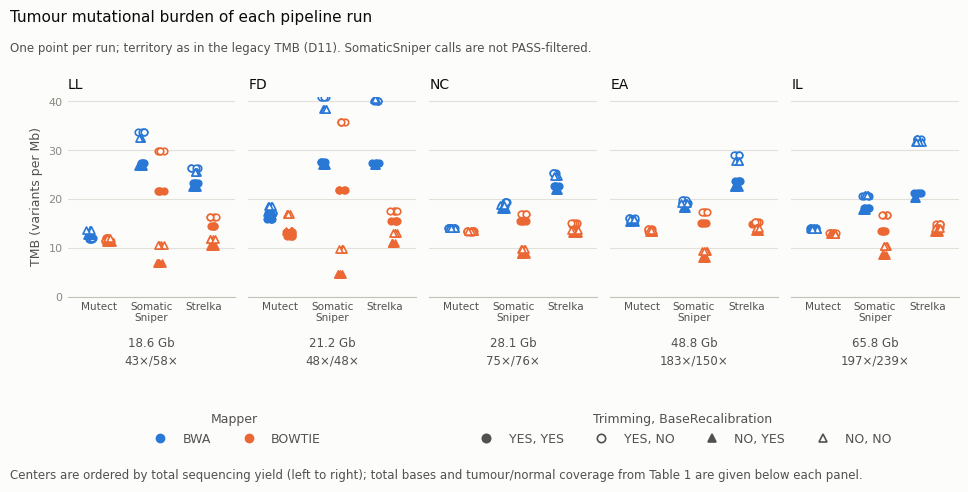

Sample,LL,FD,NC,EA,IL
VariantCaller,,,,,
Mutect,11.94,16.46,13.73,14.57,13.49
SomaticSniper,27.08,27.30,17.49,17.79,17.32
Strelka,19.38,22.31,18.36,18.81,17.48


In [7]:
fig, axes = viz.run_strips(
    runs.reset_index(), "tmb", "TMB (variants per Mb)", samples=panel_order, panel_notes=panel_notes,
    caption=viz.YIELD_CAPTION, title="Tumour mutational burden of each pipeline run",
    subtitle="One point per run; territory as in the legacy TMB (D11). SomaticSniper calls are not PASS-filtered.")
# The figure must carry the trimming legend; without it an old swb.viz is loaded in this kernel
assert "Trimming, BaseRecalibration" in [lg.get_title().get_text() for lg in fig.legends], \
    "no trimming legend in the figure: restart the kernel (an old swb.viz is loaded)"
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "tmb_by_run"))
plt.show()
# Table view: median TMB by variant caller and sample
runs.pivot_table(index="VariantCaller", columns="Sample", values="tmb", aggfunc="median")[panel_order].round(2)

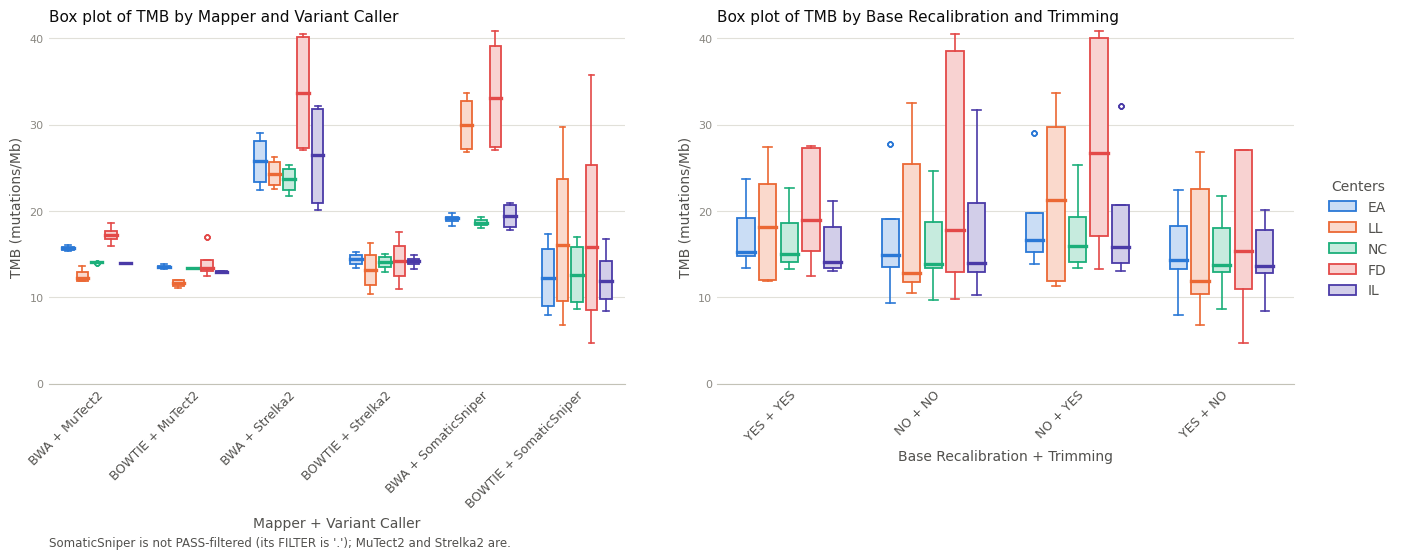

Sample                                                   EA     LL     NC   
                              category                                      
Mapper + Variant Caller       BOWTIE + Mutect         13.47  11.66  13.38  \
                              BOWTIE + SomaticSniper  12.19  16.08  12.59   
                              BOWTIE + Strelka        14.39  13.14  14.13   
                              BWA + Mutect            15.71  12.29  14.08   
                              BWA + SomaticSniper     19.15  29.91  18.67   
                              BWA + Strelka           25.75  24.31  23.67   
Base Recalibration + Trimming NO + NO                 14.90  12.83  13.87   
                              NO + YES                16.68  21.27  15.96   
                              YES + NO                14.34  11.87  13.73   
                              YES + YES               15.30  18.11  15.01   

Sample                                                   FD     IL  
                              category                              
Mapper + Variant Caller       BOWTIE + Mutect         13.37  12.96  
                              BOWTIE + SomaticSniper  15.82  11.84  
                              BOWTIE + Strelka        14.18  14.17  
                              BWA + Mutect            17.20  13.95  
                              BWA + SomaticSniper     33.04  19.44  
                              BWA + Strelka           33.68  26.45  
Base Recalibration + Trimming NO + NO                 17.79  14.00  
                              NO + YES                26.71  15.82  
                              YES + NO                15.39  13.67  
                              YES + YES               18.93  14.12

In [8]:
fig2, axes2 = viz.tmb_box_panels(
    runs.reset_index(), footnote="SomaticSniper is not PASS-filtered (its FILTER is '.'); MuTect2 and Strelka2 are.")
viz.save_fig(fig2, STAGE.stem(OUT / "figures" / "tmb_boxplots"))
plt.show()
# Table view: median TMB by the categories of both panels and centre
centre_order = list(viz.CENTER_BOX_COLOURS)
by_pair = runs.assign(category=runs["Mapper"] + " + " + runs["VariantCaller"]).pivot_table(
    index="category", columns="Sample", values="tmb", aggfunc="median")[centre_order]
by_recal_trim = runs.assign(category=runs["baseRecalibration"] + " + " + runs["isTrimmed"]).pivot_table(
    index="category", columns="Sample", values="tmb", aggfunc="median")[centre_order]
pd.concat({"Mapper + Variant Caller": by_pair, "Base Recalibration + Trimming": by_recal_trim}).round(2)

## Parity check

Against the two legacy TMB tables, `TMB` in `vcfcomparison_df_full.csv` and `tmb_list_snp.csv`: `tmb` must equal both for every run. The variant counts are checked against `Result VCF Count`, and the merged territory must *not* reproduce the legacy values (D11). The by-setting table, the figure and the merged values have no legacy counterpart and are reported as not compared. Results are moved out of staging only if every check that ran passes.

In [9]:
legacy_meta = pd.read_csv(config.LEGACY_METADATA)
legacy_meta["TestCaseNo"] = legacy_meta["TestCaseNo"].map(io.canon)
legacy_meta = legacy_meta.set_index("TestCaseNo")
legacy_tmb = pd.read_csv(config.LEGACY_TMB)
legacy_tmb["TestCase"] = legacy_tmb["TestCase"].map(io.canon)
legacy_tmb = legacy_tmb.set_index("TestCase")["TMB"]
ours = runs.set_index("TestCaseNo")

parity = audit.Parity()
parity.check("both legacy TMB tables hold exactly the {} runs".format(EXPECTED_RUNS),
             set(legacy_meta.index) == set(legacy_tmb.index) == set(ours.index), "{} runs".format(len(ours)))
n_match = int((ours["n_variants"] == legacy_meta["Result VCF Count"].reindex(ours.index)).sum())
parity.check("variants per run == legacy Result VCF Count (every run)", n_match == EXPECTED_RUNS,
             "{}/{} match".format(n_match, EXPECTED_RUNS))
d_meta = (ours["tmb"] - legacy_meta["TMB"].reindex(ours.index)).abs()
d_list = (ours["tmb"] - legacy_tmb.reindex(ours.index)).abs()
parity.check("tmb == legacy vcfcomparison_df_full TMB (every run)", d_meta.notna().all() and d_meta.max() <= TOLERANCE,
             "max |diff| {:.2e}".format(d_meta.max()))
parity.check("tmb == legacy tmb_list_snp.csv (every run)", d_list.notna().all() and d_list.max() <= TOLERANCE,
             "max |diff| {:.2e}".format(d_list.max()))
d_merged = (ours["tmb_merged"] - legacy_meta["TMB"].reindex(ours.index)).abs()
parity.check("legacy TMB is not reproduced by the merged territory (D11)", d_merged.min() > 0 and d_merged.max() > TOLERANCE,
             "max |diff| {:.2e}".format(d_merged.max()))
parity.skip("tmb_merged, tmb_by_setting.csv", "no legacy counterpart")
parity.skip("the figures and the Table 1 annotations under the panels of tmb_by_run",
            "the legacy figures were drawn from the same TMB values; the annotations come from manuscript Table 1")

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (5 checks, 2 skipped)
PASS  both legacy TMB tables hold exactly the 480 runs  [480 runs]
PASS  variants per run == legacy Result VCF Count (every run)  [480/480 match]
PASS  tmb == legacy vcfcomparison_df_full TMB (every run)  [max |diff| 7.11e-15]
PASS  tmb == legacy tmb_list_snp.csv (every run)  [max |diff| 3.55e-15]
PASS  legacy TMB is not reproduced by the merged territory (D11)  [max |diff| 2.57e-02]
SKIP  tmb_merged, tmb_by_setting.csv  [no legacy counterpart]
SKIP  the figures and the Table 1 annotations under the panels of tmb_by_run  [the legacy figures were drawn from the same TMB values; the annotations come from manuscript Table 1]



## Audit summary

In [10]:
median_by_caller = runs.groupby("VariantCaller")["tmb"].median().round(2)
lines = [
    "runs: {}; variants per run {}-{}; TMB {:.2f}-{:.2f} variants per Mb (median {:.2f})".format(
        len(runs), runs["n_variants"].min(), runs["n_variants"].max(), runs["tmb"].min(), runs["tmb"].max(),
        runs["tmb"].median()),
    "territory of {}: {:,} bp (raw sum of interval lengths, legacy; overlaps counted twice)".format(
        config.EXOME_BED.relative_to(config.REPO_ROOT).as_posix(), raw_sum_bp),
    "  merged unique length {:,} bp; tmb_merged is larger by at most {:.3f}% (D11, undecided)".format(
        merged_bp, 100 * (runs["tmb_merged"] / runs["tmb"] - 1).max()),
    "tmb reproduces the legacy TMB of both legacy tables for every run (max |diff| {:.1e})".format(max(d_meta.max(), d_list.max())),
    "SomaticSniper is not PASS-filtered (FILTER is '.' on every record; legacy exemption preserved), Mutect and Strelka are:",
    "  pass_filter_applied is False for {} runs".format(int((~runs["pass_filter_applied"]).sum())),
    "not compared with legacy: tmb_merged, tmb_by_setting.csv, the figures",
    "panel order (increasing total yield, manuscript Table 1): {}".format(", ".join(panel_order)),
    "",
    "median TMB by variant caller: {}".format(median_by_caller.to_dict()),
    "median TMB by {}: {}".format(TRIM_RECAL, runs.groupby(TRIM_RECAL)["tmb"].median().round(2).to_dict()),
    "",
    "python {} | pandas {}".format(sys.version.split()[0], pd.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs: 480; variants per run 377-3299; TMB 4.67-40.85 variants per Mb (median 15.27)
territory of data/reference/sorted_exome_hc.bed.gz: 80,762,432 bp (raw sum of interval lengths, legacy; overlaps counted twice)
  merged unique length 80,711,709 bp; tmb_merged is larger by at most 0.063% (D11, undecided)
tmb reproduces the legacy TMB of both legacy tables for every run (max |diff| 7.1e-15)
SomaticSniper is not PASS-filtered (FILTER is '.' on every record; legacy exemption preserved), Mutect and Strelka are:
  pass_filter_applied is False for 160 runs
not compared with legacy: tmb_merged, tmb_by_setting.csv, the figures
panel order (increasing total yield, manuscript Table 1): LL, FD, NC, EA, IL

median TMB by variant caller: {'Mutect': 13.5, 'SomaticSniper': 18.4, 'Strelka': 18.86}
median TMB by isTrimmed, baseRecalibration: {'NO, NO': 14.03, 'NO, YES': 13.45, 'YES, NO': 17.01, 'YES, YES': 15.4}

python 3.8.12 | pandas 2.0.0
